In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../data/processed/final_dataset.csv")

print("Shape:", df.shape)
df.head()

Shape: (590540, 434)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [3]:
X = df.drop(columns=["isFraud"])
y = df["isFraud"]

In [4]:
import sys, os
sys.path.append("../src")

from preprocessing import Preprocessor

prep = Preprocessor()

X_processed, y = prep.fit_transform(df)

print("Processed shape:", X_processed.shape)

2026-03-27 23:17:21,837 [INFO] Starting fit_transform …
2026-03-27 23:17:31,722 [INFO] Dropping 214 high-missing columns: ['dist1', 'dist2', 'R_emaildomain', 'D5', 'D6'] …
2026-03-27 23:17:33,233 [INFO] Numeric: 208  |  Categorical: 9
2026-03-27 23:18:06,569 [INFO] Saved selected features → models\selected_features.pkl
2026-03-27 23:18:06,602 [INFO] fit_transform complete. Feature count: 217


Processed shape: (590540, 217)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, stratify=y, random_state=42
)

In [6]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, n_jobs=-1),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="auc",
        use_label_encoder=False,
        n_jobs=-1
    )
}

In [7]:
results = []

for name, model in models.items():
    print(f"\n🔹 Training: {name}")
    
    model.fit(X_train, y_train)
    
    probs = model.predict_proba(X_test)[:, 1]
    preds = (probs >= 0.5).astype(int)
    
    roc = roc_auc_score(y_test, probs)
    
    results.append((name, roc))
    
    print(f"ROC-AUC: {roc:.4f}")
    print(classification_report(y_test, preds))


🔹 Training: Logistic Regression
ROC-AUC: 0.7651
              precision    recall  f1-score   support

           0       0.97      1.00      0.98    113975
           1       0.64      0.03      0.07      4133

    accuracy                           0.97    118108
   macro avg       0.80      0.52      0.52    118108
weighted avg       0.95      0.97      0.95    118108


🔹 Training: Random Forest
ROC-AUC: 0.9188
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    113975
           1       0.88      0.46      0.61      4133

    accuracy                           0.98    118108
   macro avg       0.93      0.73      0.80    118108
weighted avg       0.98      0.98      0.98    118108


🔹 Training: XGBoost
ROC-AUC: 0.9325
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    113975
           1       0.90      0.44      0.59      4133

    accuracy                           0.98    118108

In [8]:
results_df = pd.DataFrame(results, columns=["Model", "ROC-AUC"])
results_df = results_df.sort_values(by="ROC-AUC", ascending=False)

results_df

,Model,ROC-AUC
2,XGBoost,0.932540
1,Random Forest,0.918794
0,Logistic Regression,0.765097


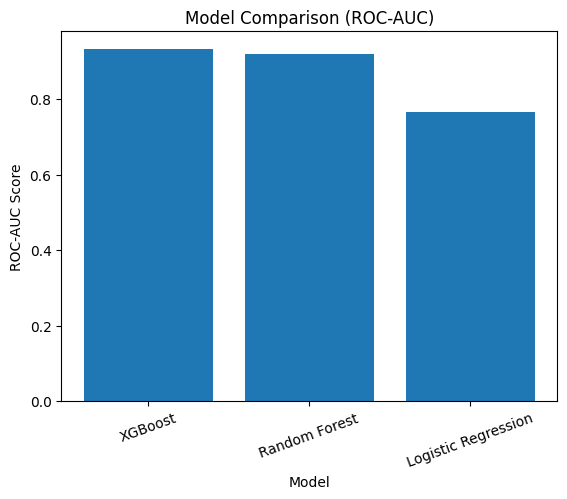

In [9]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(results_df["Model"], results_df["ROC-AUC"])
plt.title("Model Comparison (ROC-AUC)")
plt.xlabel("Model")
plt.ylabel("ROC-AUC Score")
plt.xticks(rotation=20)
plt.show()

### **Conclusion**

- XGBoost achieved the highest ROC-AUC score.
- It handles imbalanced data better than other models.
- It captures complex patterns effectively.

Therefore, XGBoost was selected as the final model for the fraud detection system.